# Bayesian Machine Learning
## Assignment 0: Introduction to Jax (pass/fail)

    Name: Tejas Dharmale
    Student: s1190137

In [1]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.random import PRNGKey

In this assignment, we will learn how to use the Jax framework for efficient parallel computation and automatic differentiation (for install see https://jax.readthedocs.io/en/latest/installation.html). While much of the jax API is similar to NumPy, there are some important differences. We recommend to look at the following articles before starting the assignment:

- [Jax Quickstart](https://jax.readthedocs.io/en/latest/notebooks/quickstart.html)
- [Jax vs. NumPy](https://jax.readthedocs.io/en/latest/notebooks/thinking_in_jax.html)

## Exercise 1.1

Generate 100 keys and use jax.vmap to sample from a normal distribution with each key. Verify they do not generate the same samples, but their statistics (mean, variance) are correct.

In [2]:
import jax
import jax.numpy as jnp

key = jax.random.PRNGKey(0)
keys = jax.random.split(key, 100)

In [4]:
def sample(k):
    return jax.random.normal(k)

samples = jax.vmap(sample)(keys)

print("All unique:", len(jnp.unique(samples)) == 100)
print("First 10 samples:", samples[:10])


print("Mean:", jnp.mean(samples))

All unique: True
First 10 samples: [ 1.0040143  -2.4424558   1.2956359  -0.6219436  -1.0208853   0.63737714
  1.1634994  -0.06259047 -0.6458575   0.07209862]
Mean: -0.12851442


## Exercise 1.2
Use jax.lax.scan() to compute the first 10 elements that come after 0 and 1 in Fibonacci sequence:

\begin{align}
    f_0&= 0\\
    f_1&= 1\\
    f_n&=f_{n-2}+f_{n-1},\text{for}n>1
\end{align}

Resulting in the sequence: $x_n=\{1,2,3,5,8,13,21,34,55,89\}$

In [17]:
# My understanding of the problem
# Question 1] why didn't we used vmap and why are we using lax.scan method here?

# vmap is for independent work. Every item can be computed at the same time because none of them need each other's results.
# scan is for dependent, sequential work. Each step needs the answer from the previous step, so they must happen in order, one after another.

# Solution: take two thing carry and 2nd is output for fibo we only need to remember last two values of fibo.
# Starting state: (a, b) = (0, 1)
# The next number is a + b.
# Then I shift my memory forward: the new pair becomes (b, a+b).
# I save a + b as the output.


In [20]:
def step(carry, x):
    a, b = carry
    next_val = a + b
    new_carry = (b, next_val)
    return new_carry, next_val

init = (0, 1)

final_carry, sequence = jax.lax.scan(step, init, xs=None, length=10)

print(sequence)

[ 1  2  3  5  8 13 21 34 55 89]


## Exercise 1.3: The gradient of the log Posterior
Throughout this course, we will encounter many posterior distributions. As a starting point in using the Jax framework for efficient inference of complex posteriors, we consider an example of a Beta-Bernoulli coin toss model, described as:

\begin{align}
 p(\theta) &= \text{Beta} (\theta \mid a, b) &&  \qquad \text{(Prior)} \\
 p(y_i \mid \theta) &= \text{Bernoulli}(y_i \mid \theta)  && \qquad \text{(Likelihood)}
\end{align}

Understand how the function below computes the log posterior. Then:

a. Visualize for a range of theta in its support the posterior and log-posterior.

b. Create your own set of observations (binary), and append it to the list of data. Observe and comment on how the posterior density changed.

c. Use Jax's autograd functionality to obtain gradients from the log posterior. Visualize the log gradient, where is it 0? Comment on how one could use the gradient to find the Maximum A Posteriori (MAP) estimate, and when this procedure could potentially fail.

In [ ]:
#question 1.3a)
##Visualize for a range of theta in its support the posterior and log-posterior.

In [41]:
from jax.scipy.stats import beta, bernoulli
import matplotlib.pyplot as plt

alpha_prior, beta_prior = 1.0, 1.0
data = jnp.array([1, 1, 0, 1, 0, 0, 0, 1, 0, 0])

@jax.jit
def log_posterior(theta, data, alpha_param, beta_param):
    """Computes the unnormalized log-posterior."""
    theta = jnp.clip(theta, 1e-7, 1-1e-7)
    log_prior = beta.logpdf(theta, alpha_param, beta_param)
    log_likelihood = bernoulli.logpmf(data, theta).sum()
    return log_prior + log_likelihood

thetas = jnp.linspace(0.001, 0.999, 200)

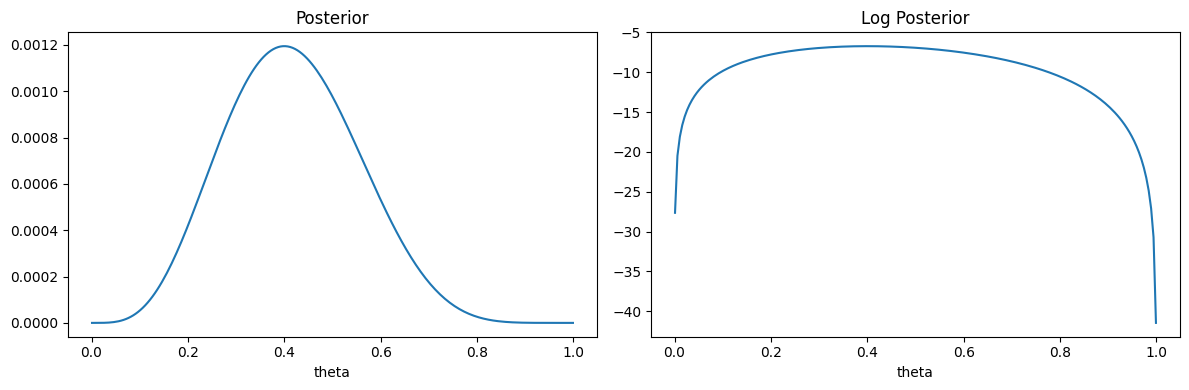

In [42]:
log_post_vals = jax.vmap(log_posterior, in_axes=(0, None, None, None))(thetas, data, alpha_prior, beta_prior)
post_vals = jnp.exp(log_post_vals)   # undo the log to get the posterior

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(thetas, post_vals)
ax[0].set_title("Posterior")
ax[0].set_xlabel("theta")
ax[1].plot(thetas, log_post_vals)
ax[1].set_title("Log Posterior")
ax[1].set_xlabel("theta")
plt.tight_layout()
plt.show()

In [35]:
# Summay for question 1]

# the log posterior across a grid of theta values using vmap for efficient parallel computation

# Summary of both graph:
# Posterior:
#it is easy to interpret, the hump clearly shows the most likely value of theta and how confident we are.
# The disadvantage I found is the values near theta = 0 and 1 look flat at zero, hiding detail, and the tiny numbers are prone to numerical underflow.

# Log Posterior:
# it is numerically stable and keeps the peak at the exact same theta, making it ideal for computing gradients and finding the MAP.
# it is less intuitive to read, the negative stretched scale does not look like a familiar probability distribution is one of the major disadvantage it has.


In [36]:
# question 1.3b)
#Create your own set of observations (binary), and append it to the list of data. Observe and comment on how the posterior density changed

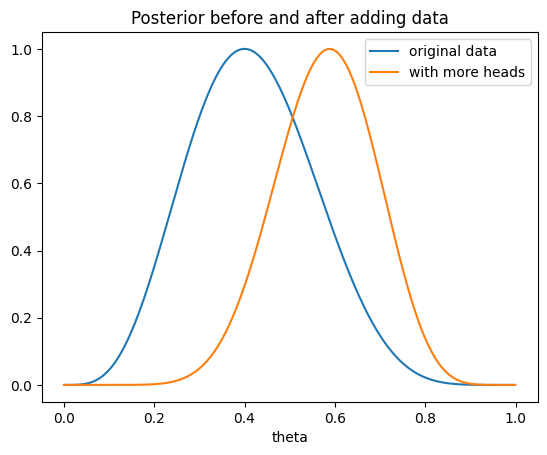

In [43]:
my_data = jnp.array([1, 1, 1, 1, 1])
new_data = jnp.concatenate([data, my_data])

log_post_new = jax.vmap(log_posterior, in_axes=(0, None, None, None))(thetas, new_data, a, b)
post_new = jnp.exp(log_post_new)

# Normalize each to peak = 1 so the shapes are comparable
plt.plot(thetas, post_vals / jnp.max(post_vals), label="original data")
plt.plot(thetas, post_new / jnp.max(post_new), label="with more heads")
plt.title("Posterior before and after adding data")
plt.xlabel("theta")
plt.legend()
plt.show()

In [38]:
# Summary
# I Think adding more heads shifted the posterior peak to the right, toward higher theta.
# Also hump became narrower, showing reduced uncertainty.
# I think professor that with Bayesian updating the more data we collect the more the posterior narrows around the value the data points to, showing we are more confident.

In [40]:
#  question 1.3c)
# Use Jax's autograd functionality to obtain gradients from the log posterior. Visualize the log gradient, where is it 0? Comment on how one could use the gradient to find the Maximum A Posteriori (MAP) estimate, and when this procedure could potentially fail.

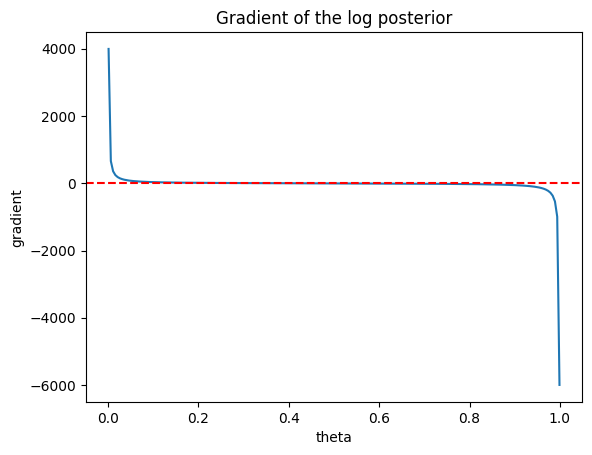

MAP estimate: 0.4


In [44]:

grad_log_post = jax.grad(log_posterior, argnums=0)

grad_vals = jax.vmap(grad_log_post, in_axes=(0, None, None, None))(thetas, data, alpha_prior, beta_prior)


plt.plot(thetas, grad_vals)
plt.axhline(0, color="red", linestyle="--")
plt.title("Gradient of the log posterior")
plt.xlabel("theta")
plt.ylabel("gradient")
plt.show()

theta = 0.5
lr = 0.01
for _ in range(500):
    g = grad_log_post(theta, data, alpha_prior, beta_prior)
    theta = theta + lr * g
print("MAP estimate:", theta)

In [46]:
#Summary: The gradient points uphill, so to find the MAP we start at any theta and keep stepping in the direction of the gradient until it reaches zero . The point where the gradient is zero is the peak of the log posterior, which is the MAP.

#It only fails near edge when theta is 0 or 1

## Exercise 1.4: The vmap function for Bayesian inference

A major benefit of the Jax framework is its fast parallel computation. In particular, the vmap function is a powerful tool to compute batched operations in parallel. Next, we will use this function to write an efficient Bayesian inference example, leveraging parallel computation.
### A logistic regression model
To practice with parallel computation in a slightly more realistic setting, you are given the log joint likelihood of a logistic regression model. This is given as:

\begin{equation}
    p(y=1 \mid \boldsymbol{x}, \boldsymbol{\beta}) = \sigma ( \boldsymbol{\beta}^{\top}\boldsymbol{x})
\end{equation}
where $\boldsymbol{x}$ are the inputs, $\boldsymbol{\beta}$ are the input features, and $\sigma ( \cdot )$ is the sigmoid function. Ultimately, the goal is to update the input features of the model for a given dataset $\mathcal{D} = \{(\boldsymbol{x}_1, y_1), \dots, (\boldsymbol{x}_N, y_N)\}$.

To make this a probabilistic model, we consider A) a $\textit{prior}$ on the input features $\boldsymbol{\beta}$, and B) a $\textit{likelihood}$ function for a given set of input features. For the prior, we use a Gaussian belief $ p(\boldsymbol{\beta}) \sim  \mathcal{N}(0,1)$. For the likelihood, we use a Bernoulli likelihood, similar to the earlier coinflip model: $p(y\mid \boldsymbol{x}, \boldsymbol{\beta}) = \text{Bernoulli}(\sigma (\boldsymbol{\beta}^{\top}\boldsymbol{x})  )$.

The joint probability can be obtained by considering the inputs as well as the input features: $p(y,\boldsymbol{\beta} \mid x)$. Using standard probability results, we can factor this to: $\text{log } p(y,\boldsymbol{\beta} \mid x) = \log p(\boldsymbol{\beta}) + \log p(y\mid \boldsymbol{x}, \boldsymbol{\beta})$. This is already implemented in the function below.



In [49]:
import numpy as np
import scipy as sp
import jax.scipy as jsp

D = 10
N = 88

true_beta = np.random.randn(D).astype(jnp.float32)
X = np.random.randn(N, D).astype(jnp.float32)
y = (np.random.rand(N) < sp.special.expit(X.dot(true_beta))).astype(jnp.int32)

def log_joint(beta):
    """
        Computes the log joint probability of a single set of input features (D=10).
    """
    # Log Prior - p(Beta) ~ N(0,1)
    result = 0.
    result = result + jnp.sum(jsp.stats.norm.logpdf(beta, loc=0., scale=1.))
    # Log Likelihood - p(y | X, Beta) ~ Bernoulli, with a logistic function.
    result = result + jnp.sum(-jnp.log(1 + jnp.exp(-(2*y-1) * jnp.dot(X, beta))))
    return result

X.shape, y.shape

((88, 10), (88,))

First, understand the code given above, which generates a fake binary classification dataset of $N=88$ datapoints with $D=10$ features.  Then:

a. Write a naïve function that generates $M=100$ random input features $\boldsymbol{\Beta} \in \mathbb{R}^{M\times D}$, and evaluates the log probability density function on each feature set in a for loop.

b. Write a function that generates the same output, but uses jax.vmap() function. Compare the computation times using the command '%timeit' command. What happens to the time when you jit the log joint function?

c. Write a function that uses $\textit{another}$ vmap() to compute the log density of $b=10$ batches, each of size $s=10$. (note: the batched matrix size is now: $[b,s,D]$).


In [47]:
# example use of the timeit function
matrix1, matrix2 = jnp.ones((1000, 1000)), jnp.ones((1000, 1000))
%timeit jnp.matmul(matrix1, matrix2)

35.9 ms ± 5.86 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [61]:
#Question 1.4a]

In [59]:
M = 100
key = jax.random.PRNGKey(0)
B = jax.random.normal(key, (M, D))


def naive_log_joint(B):
    results = []
    for i in range(B.shape[0]):
        results.append(log_joint(B[i]))
    return jnp.array(results)

out_naive = naive_log_joint(B)
print(out_naive.shape)

# --- Part b: vmap version ---
vmap_log_joint = jax.vmap(log_joint)
out_vmap = vmap_log_joint(B)
print(out_vmap.shape)


# Check both give the same answer
print(jnp.allclose(out_naive, out_vmap))

(100,)
(100,)
True


In [62]:
#question 1.4b]

In [60]:

vmap_log_joint = jax.vmap(log_joint)

out_vmap = vmap_log_joint(B)
print(out_vmap.shape)
print(jnp.allclose(naive_log_joint(B), out_vmap))


print("Naive for loop:")
%timeit naive_log_joint(B)

print("vmap:")
%timeit vmap_log_joint(B)


jit_log_joint = jax.jit(jax.vmap(log_joint))
jit_log_joint(B)

print("vmap + jit:")
%timeit jit_log_joint(B)

(100,)
True
Naive for loop:
151 ms ± 18.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
vmap:
5.82 ms ± 703 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
vmap + jit:
66.3 µs ± 9.88 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [63]:
n_batches = 10
batch_size = 10
B_batch = jnp.reshape(B, (n_batches, batch_size,D))
print(B_batch.shape)

(10, 10, 10)


In [64]:
# Question 1.4c]

In [65]:
batched_log_joint = jax.vmap(jax.vmap(log_joint))

out_batched = batched_log_joint(B_batch)
print(out_batched.shape)

(10, 10)
